In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

import config
import comborun
import autoencoder
from config import generate_full_paths, ps_data_ranges

from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn



In [2]:
all_thbn = np.load(f'{config.DATA_DIR}/thumbnails.npy')
train_data = autoencoder.process_thumbnails(all_thbn)


In [3]:




# Convert to PyTorch Tensors
# Filter out the empty (zero) thumbnails first!
valid_mask = train_data.sum(axis=(1, 2, 3)) > 0
data_tensor = torch.tensor(train_data[valid_mask], dtype=torch.float32)

dataset = TensorDataset(data_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = autoencoder.ParticleAE(latent_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Loop
epochs = 50
for epoch in range(epochs):
    total_loss = 0
    for batch in loader:
        img = batch[0].to(device)
        
        # Forward
        recon, _ = model(img)
        loss = criterion(recon, img)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(loader):.6f}")

/home/pat/miniconda3/envs/spts-stable/lib/python3.10/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5070 Ti with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5070 Ti GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


KeyboardInterrupt: 

In [4]:
model_path = f"{config.DATA_DIR}/model.pth"

# Save the weights
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")



Model saved to /home/pat/spts-ana/data/model.pth


In [5]:

all_thbn = np.load(f'{config.DATA_DIR}/thumbnails.npy')

train_data = autoencoder.process_thumbnails(all_thbn)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = autoencoder.ParticleAE(latent_dim=32).to(device)
model.load_state_dict(torch.load(f"{config.DATA_DIR}/model.pth", map_location=device))
valid_mask = train_data.sum(axis=(1, 2, 3)) > 0
data_tensor = torch.tensor(train_data[valid_mask], dtype=torch.float32)

model.eval()
i = 250
with torch.no_grad():
    # Grab a few samples from your data_tensor
    sample_input = data_tensor[i:i+5].to(device)
    recon,_ = model(sample_input)



/tmp/ipykernel_21452/3634683504.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{config.DATA_DIR}/model.pth", map_location=device))


In [5]:

plt.imshow(np.array(recon[0,0].cpu()))

AttributeError: 'Tensor' object has no attribute 'gpu'

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(sample_input[i, 0].cpu(), vmin=0, vmax=1)
    axes[0, i].set_title("Original")
    axes[1, i].imshow(recon[i, 0].cpu(), vmin=0, vmax=1)
    axes[1, i].set_title("Reconstructed")
plt.show()

In [34]:
from umap import UMAP # or from sklearn.manifold import TSNE

# UMAP is generally faster and better for clusters
reducer = UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean')
embedding = reducer.fit_transform(latent_vectors)

plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='Spectral', s=5)

/home/pat/miniconda3/envs/spts-gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'latent_vectors' is not defined

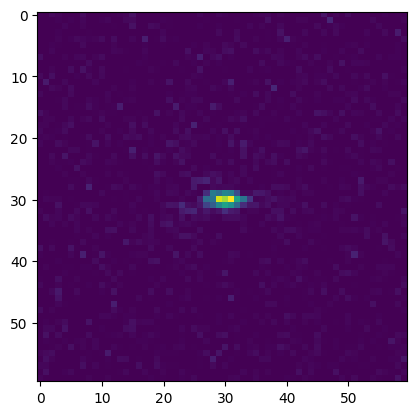

In [70]:
loc = np.where(np.logical_and(coords[:, 0]<-10, coords[:, 1]>0))
#loc = np.where(np.logical_and(coords[:, 0]>0, coords[:, 1]<0))

plt.imshow(thumbnails[np.random.choice(loc[0])])
#print(loc)

(1818, 2)


Text(0.5, 1.0, 'Most Extreme Morphology: Index 41')

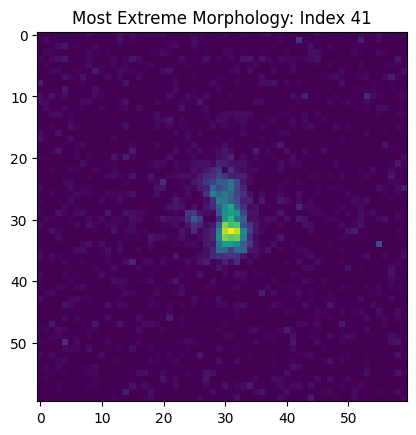

In [69]:
print(coords.shape)
# Find the index of the particle with the highest PCA 1 value
extreme_idx = np.argmin(coords[cbr1.filter, 0])

# Plot that specific thumbnail
plt.imshow(thumbnails[extreme_idx])
plt.title(f"Most Extreme Morphology: Index {extreme_idx}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/tmp/ipykernel_1910559/1271546090.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{config.DATA_DIR}/model.pth", map_location=device))

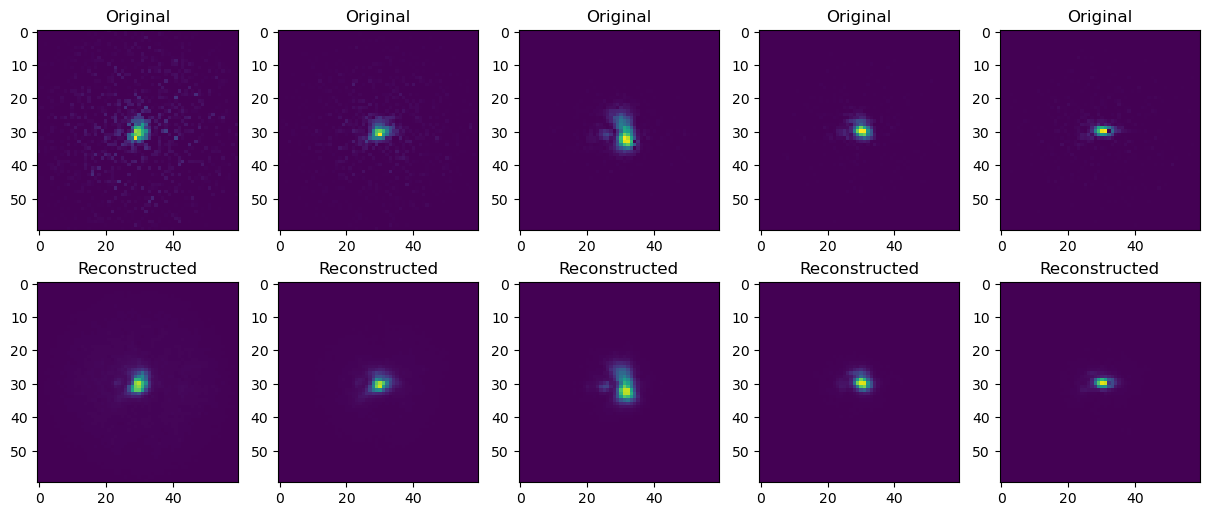

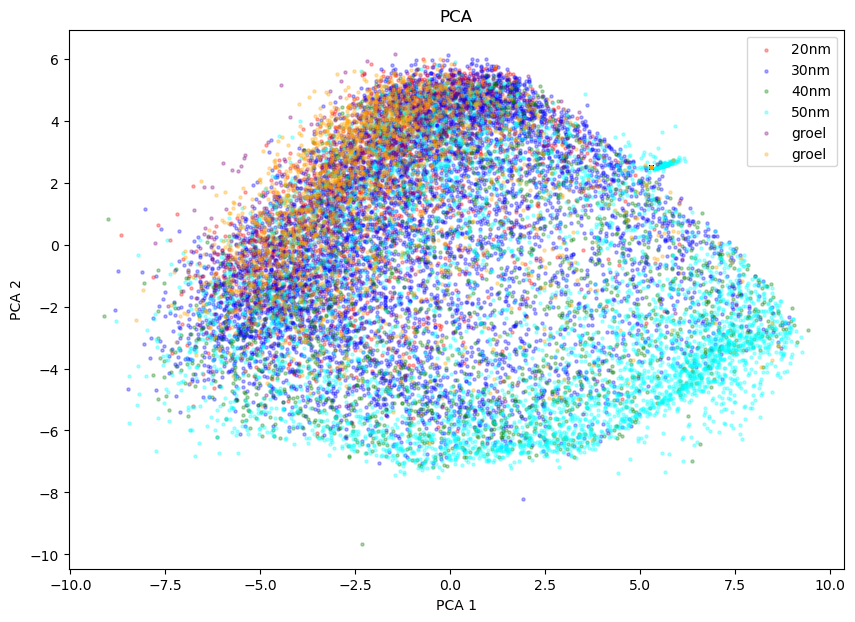

In [42]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

import config
import comborun
import autoencoder
from config import generate_full_paths, ps_data_ranges
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn


all_thbn = np.load(f'{config.DATA_DIR}/thumbnails.npy')

proc_thbn = autoencoder.process_thumbnails(all_thbn)
train_data = proc_thbn[:]


# 1. Re-create the model structure
model = autoencoder.ParticleAE(latent_dim=32).to(device)

# 2. Load the weights into that structure
model.load_state_dict(torch.load(f"{config.DATA_DIR}/model.pth", map_location=device))

# 3. Set to evaluation mode (important for consistent results!)
model.eval()

model.eval()
i = 250
with torch.no_grad():
    # Grab a few samples from your data_tensor
    sample_input = data_tensor[i:i+5].to(device)
    recon, _ = model(sample_input)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(sample_input[i, 0].cpu(), vmin=0, vmax=1)
    axes[0, i].set_title("Original")
    axes[1, i].imshow(recon[i, 0].cpu(), vmin=0, vmax=1)
    axes[1, i].set_title("Reconstructed")
plt.show()
labels = [0 for _ in range(1818)]
labels+= [1 for _ in range(6524)]
labels+= [2 for _ in range(2204)]
labels+= [3 for _ in range(5392)]
labels+= [4 for _ in range(1136)]
labels+= [5 for _ in range(2023)]
labels=np.array(labels)
           


plt.figure(figsize=(10, 7))
plt.scatter(coords[labels==0, 0], coords[labels==0, 1], s=5, alpha=0.3, label='20nm', color='red')
plt.scatter(coords[labels==1, 0], coords[labels==1, 1], s=5, alpha=0.3, label='30nm', color='blue')
plt.scatter(coords[labels==2, 0], coords[labels==2, 1], s=5, alpha=0.3, label='40nm', color='green')
plt.scatter(coords[labels==3, 0], coords[labels==3, 1], s=5, alpha=0.3, label='50nm', color='cyan')
plt.scatter(coords[labels==4, 0], coords[labels==4, 1], s=5, alpha=0.3, label='groel', color='purple')
plt.scatter(coords[labels==5, 0], coords[labels==5, 1], s=5, alpha=0.3, label='groel', color='orange')
plt.title("PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()